# Getting started

## Context

`regional-pv`, a Python library that provides a weather-to-photovoltaics modelling workflow.

## Import libraries

In [3]:
# uncomment and run lines in this cell if any of the libraries are missing
# !pip install matplotlib
# !pip install notebook

In [4]:
import matplotlib.pyplot as plt  # for plotting
import numpy as np  # to handle numerical arrays
import pvlib  # to access example meteo data

from regional_pv.core import spv_workflow  # running the regional_pv package

## Define location and obtain example input data

In [5]:
# site coordinates
lat = 39
lon = -9

In [34]:
# pvlib provides accessible APIs to request data from various sources
# typical meteorological year (TMY) data from PVGIS is one example
df = pvlib.iotools.get_pvgis_tmy(lat, lon, coerce_year=2014)[0]

# make data timezone naive
df.index = df.index.tz_localize(None)

# surface solar radiation downwards (or global horizontal irradiation)
ssrd = df["ghi"].values.reshape(-1, 1)
# air temperature, at 2-m height
t2m = df["temp_air"].values.reshape(-1, 1)

print(df[["ghi", "temp_air"]].head(10))

                      ghi  temp_air
time(UTC)                          
2014-01-01 00:00:00   0.0     10.48
2014-01-01 01:00:00   0.0     10.12
2014-01-01 02:00:00   0.0      9.76
2014-01-01 03:00:00   0.0      9.40
2014-01-01 04:00:00   0.0      9.03
2014-01-01 05:00:00   0.0      8.67
2014-01-01 06:00:00   0.0      8.31
2014-01-01 07:00:00   0.0      7.95
2014-01-01 08:00:00   6.0      9.36
2014-01-01 09:00:00  75.0      9.67


## Example 1: single-valued module tilt an azimuth

A portfolio of PV installations may be described by a single value of module tilt and azimuth (e.g. the portfolio mean).

In [41]:
meta = [df.index, lon, lat]

# PV parameter values
# module tilt, degrees
tilt = 30
# module azimuth, degrees (180 is South)
azim = 180
# weights when considering multiple module orientations (see example 2)
w_orient = 1
# Ross factor, related to module temperatuce (see example 3)
th_coef = 20.8

Text(0.5, 1.0, 'Hourly PV for 30° South-oriented')

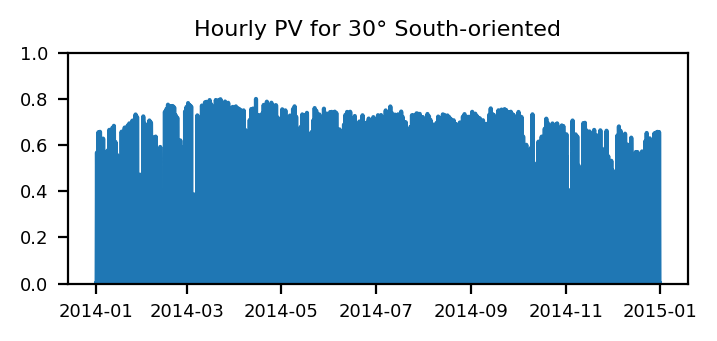

In [42]:
pv = spv_workflow(
    pv_type="non-tracking",
    ssrd=ssrd,
    t2m=t2m,
    meta=meta,
    azim=azim,
    tilt=tilt,
    w_orient=w_orient,
    th_coef=th_coef,
)

plt.figure(figsize=[4, 1.5], dpi=200)
plt.plot(df.index, pv)
plt.ylim([0, 1])
plt.tick_params(axis="both", labelsize=6.5)
plt.title("Hourly PV for 30° South-oriented", {"fontsize": 8})

## Example 2: multi-valued module tilt an azimuth

But the tilt and azimuth of that same portfolio can also be described using a distribution of values. For example, we could assume that it is equally distributed between South, South-East, and South-West orientations:

In [ ]:
# update PV parameters
tilt = np.array([30, 30, 30])
azim = np.array([180, 180 + 45, 180 - 45])
w_orient = [1 / 3, 1 / 3, 1 / 3]

Text(0.5, 1.0, 'Hourly PV for 30° PV (1/3 South, 1/3 SW, 1/3 SE)')

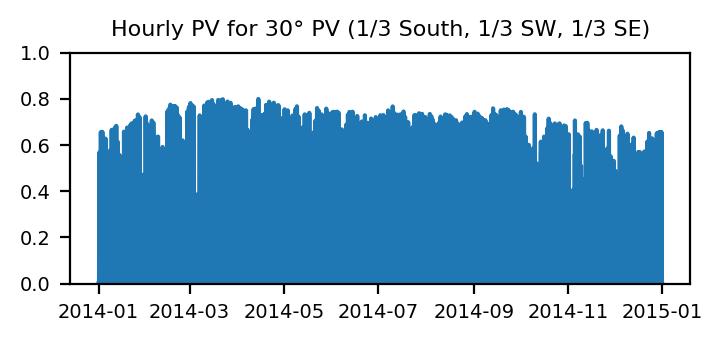

In [43]:
pv = spv_workflow(
    pv_type="non-tracking",
    ssrd=ssrd,
    t2m=t2m,
    meta=meta,
    azim=azim,
    tilt=tilt,
    w_orient=w_orient,
    th_coef=th_coef,
)

plt.figure(figsize=[4, 1.5], dpi=200)
plt.plot(df.index, pv)
plt.ylim([0, 1])
plt.tick_params(axis="both", labelsize=7)
plt.title("Hourly PV for 30° PV (1/3 South, 1/3 SW, 1/3 SE)", {"fontsize": 8})

## Example 3: changing the thermal behavior of the PV modules

`regional-pv` also allows describing how the module temperature is impacted by the module placement, namely through a Ross coefficient (`k`, in mW/cm<sup>-2</sup>). Let's compare a free-standing system (`k`=20.8) against a poorly-ventilated sloped roof (`k`=34.2).

*Source: [Skoplaki (2008)](https://www.sciencedirect.com/science/article/abs/pii/S0960148108001353).

In [48]:
th_coef1 = 20.8  # free-standing (ventilated)
th_coef2 = 34.2  # poorly-ventilated sloped roof

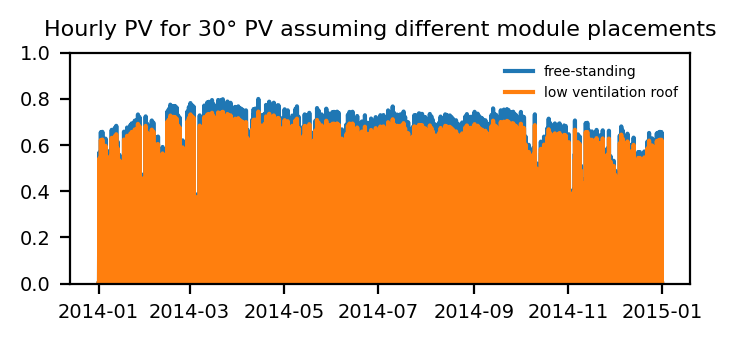

In [49]:
pv1 = spv_workflow(
    pv_type="non-tracking",
    ssrd=ssrd,
    t2m=t2m,
    meta=meta,
    azim=azim,
    tilt=tilt,
    w_orient=w_orient,
    th_coef=th_coef1,
)

pv2 = spv_workflow(
    pv_type="non-tracking",
    ssrd=ssrd,
    t2m=t2m,
    meta=meta,
    azim=azim,
    tilt=tilt,
    w_orient=w_orient,
    th_coef=th_coef2,
)

plt.figure(figsize=[4, 1.5], dpi=200)
plt.plot(df.index, pv1)
plt.plot(df.index, pv2)
plt.ylim([0, 1])
plt.tick_params(axis="both", labelsize=7)
plt.title(
    "Hourly PV for 30° PV assuming different module placements", {"fontsize": 8}
)
plt.legend(["free-standing", "low ventilation roof"], fontsize=5, frameon=False)